# Radar stabilogram extrcation 

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

In [156]:
# df = pd.read_csv("../data/antoine/radar24/test4.csv")
# df = pd.read_csv("../results/kelly/X_vitesse.csv")
df = pd.read_csv("./testML.csv")
x_time = df["Time_s"].values
x_velocity = df["Vmax_m_s"].values
x_pos = cumulative_trapezoid(x_velocity, x_time, initial=0)


# df = pd.read_csv("../data/antoine/radar9/test4.csv")
# df = pd.read_csv("../results/kelly/Y_vitesse.csv")
df = pd.read_csv("./testAP.csv")
y_time = df["Time_s"].values
y_velocity = df["Vmax_m_s"].values
y_pos = cumulative_trapezoid(y_velocity, y_time, initial=0)


In [157]:
# positive_time = np.where((x_time >= 0) & (x_time <= 10))
positive_time = np.where((x_time >= 0))
x_pos = x_pos[positive_time]
x_time = x_time[positive_time]

In [158]:
# common_times = np.linspace(0, 10, len(y_pos))
# signal_x_resampled = np.interp(common_times, x_time, x_pos)
# signal_y_resampled = np.interp(common_times, y_time, y_pos)

# x_pos = signal_x_resampled
# y_pos = signal_y_resampled
# x_time = common_times
# y_time = common_times

In [159]:
x_pos = x_pos*1000
y_pos = y_pos*1000

In [160]:
1/x_time[1]

np.float64(17.20000000000001)

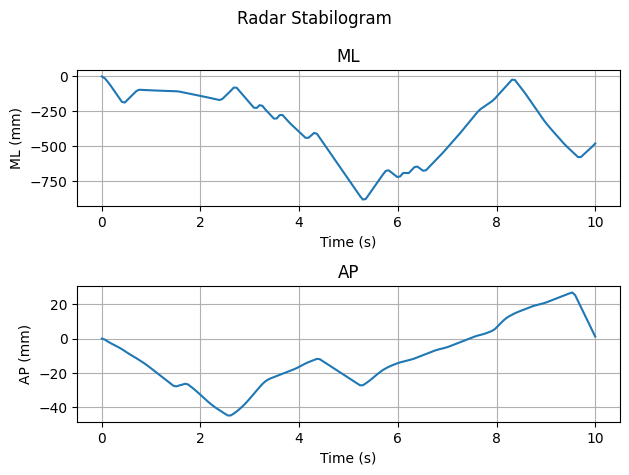

In [161]:

plt.figure()
plt.suptitle("Radar Stabilogram")

# Plot X
plt.subplot(2, 1, 1)
plt.plot(x_time, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("ML (mm)")
plt.title("ML")
plt.grid()

# Plot Y
plt.subplot(2, 1, 2)
plt.plot(y_time, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("AP (mm)")
plt.title("AP")
plt.grid()

plt.tight_layout()
plt.show()


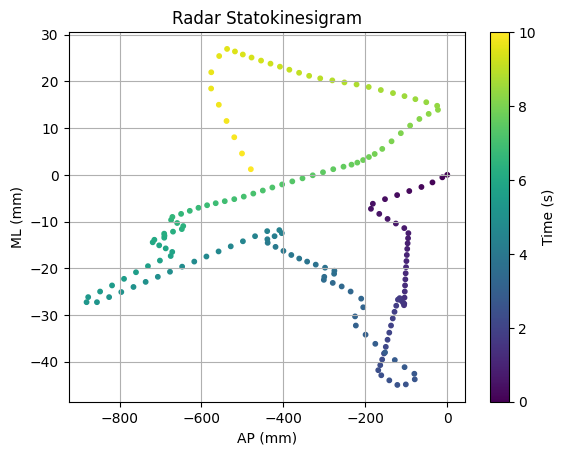

In [162]:

plt.figure()
sc = plt.scatter(x_pos, y_pos, c=y_time, cmap='viridis', s=10)
plt.xlabel("AP (mm)")
plt.ylabel("ML (mm)")
plt.title("Radar Statokinesigram")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

## Centering

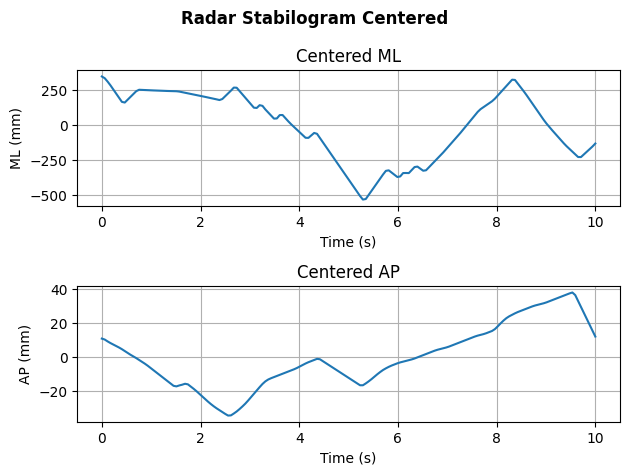

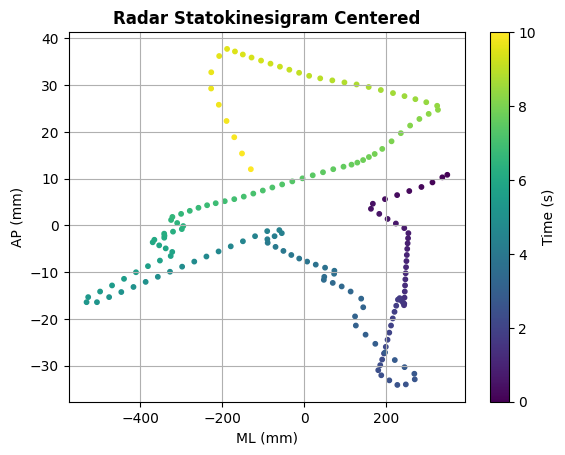

In [163]:
x_pos = x_pos - np.mean(x_pos)
y_pos = y_pos - np.mean(y_pos)

# sauvegarder en CSV
df = pd.DataFrame({
    "time": y_time,
    "x_pos": x_pos,
    "y_pos": y_pos
})

df.to_csv("../results/antoine/test4_position.csv", index=False)

plt.figure()
plt.suptitle("Radar Stabilogram Centered", fontweight='bold')

# Plot X
plt.subplot(2, 1, 1)
plt.plot(y_time, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("ML (mm)")
plt.title("Centered ML")
plt.grid()

# Plot Y
plt.subplot(2, 1, 2)
plt.plot(y_time, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("AP (mm)")
plt.title("Centered AP")
plt.grid()

plt.tight_layout()
plt.show()

plt.figure()
sc = plt.scatter(x_pos, y_pos, c=y_time, cmap='viridis', s=10)
plt.xlabel("ML (mm)")
plt.ylabel("AP (mm)")
plt.title("Radar Statokinesigram Centered", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

## Normalization 

In [ ]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

plt.figure()
sc = plt.scatter(x_norm, y_norm, c=y_time, cmap='viridis', s=10)
plt.xlabel("ML (mm)")
plt.ylabel("AP (mm)")
plt.title("Radar Statokinesigram Normalized testing")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [ ]:
data = np.array([x_pos/10, y_pos/10]).T

stato = Stabilogram()
stato.from_array(array=data, original_frequency=1/y_time[1])

sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [166]:

def get_descriptors(x_pos, y_pos, time):
    data = np.array([x_pos/10, y_pos/10]).T

    stato = Stabilogram()
    stato.from_array(array=data, original_frequency=1/time[1])
    sway_density_radius = 0.3 # 3 mm
    params_dic = {"sway_density_radius": sway_density_radius}
    features = compute_all_features(stato, params_dic=params_dic)

    return features 
    

## Save dataset1 radar stabilograms and descriptors

In [167]:
def get_position_filtered(x_velocity_file, y_velocity_file, output_file=None):

    df = pd.read_csv(x_velocity_file)
    x_time = df["Time_s"].values
    x_velocity = df["Vmax_m_s"].values
    x_pos = cumulative_trapezoid(x_velocity, x_time, initial=0)

    df = pd.read_csv(y_velocity_file)
    y_time = df["Time_s"].values
    y_velocity = df["Vmax_m_s"].values
    y_pos = cumulative_trapezoid(y_velocity, y_time, initial=0)

    # Cutting over 10 seconds, because one of the radar recorded over
    common_times = np.linspace(0, 10, len(y_pos))
    signal_x_resampled = np.interp(common_times, x_time, x_pos)
    signal_y_resampled = np.interp(common_times, y_time, y_pos)

    x_pos = signal_x_resampled
    y_pos = signal_y_resampled
    x_time = common_times
    y_time = common_times

    x_pos = x_pos*1000
    y_pos = y_pos*1000

    x_pos = x_pos - np.mean(x_pos)
    y_pos = y_pos - np.mean(y_pos)

    if output_file is not None:
        df = pd.DataFrame({
            "time": y_time,
            "x_pos": x_pos,
            "y_pos": y_pos
        })
        print("savin")

        df.to_csv(output_file, index=False)
        
    return x_pos, y_pos, y_time


In [169]:

features_list = []

for i in range(1, 6):
    ml_file = f"../results/tables/dataset1/velocity/data{i}_ML_velocity.csv"
    ap_file = f"../results/tables/dataset1/velocity/data{i}_AP_velocity.csv"

    print(ap_file, ml_file)
    x_pos, y_pos, time = get_position_filtered(ml_file, ap_file, f"../results/tables/dataset1/position/data{i}_radarposition.csv")
    features = get_descriptors(x_pos, y_pos, time)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset1/radar_descriptors.csv")


../results/tables/dataset1/velocity/data1_AP_velocity.csv ../results/tables/dataset1/velocity/data1_ML_velocity.csv
savin
../results/tables/dataset1/velocity/data2_AP_velocity.csv ../results/tables/dataset1/velocity/data2_ML_velocity.csv
savin
../results/tables/dataset1/velocity/data3_AP_velocity.csv ../results/tables/dataset1/velocity/data3_ML_velocity.csv
savin
../results/tables/dataset1/velocity/data4_AP_velocity.csv ../results/tables/dataset1/velocity/data4_ML_velocity.csv
savin


C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 246, using nperseg = 246
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 246, using nperseg = 246
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 246, using nperseg = 246
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


../results/tables/dataset1/velocity/data5_AP_velocity.csv ../results/tables/dataset1/velocity/data5_ML_velocity.csv
savin


C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 245, using nperseg = 245
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 245, using nperseg = 245
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


In [ ]:
df_features

## Save dataset2 stabilograms and descriptors

In [ ]:
def get_position(x_velocity_file, y_velocity_file, output_file=None):

    df = pd.read_csv(x_velocity_file)
    x_time = df["Time_s"].values
    x_velocity = df["Vmax_m_s"].values
    x_pos = cumulative_trapezoid(x_velocity, x_time, initial=0)

    df = pd.read_csv(y_velocity_file)
    y_time = df["Time_s"].values
    y_velocity = df["Vmax_m_s"].values
    y_pos = cumulative_trapezoid(y_velocity, y_time, initial=0)

    x_pos = x_pos*1000
    y_pos = y_pos*1000

    x_pos = x_pos - np.mean(x_pos)
    y_pos = y_pos - np.mean(y_pos)

    if output_file is not None:
        df = pd.DataFrame({
            "time": y_time,
            "x_pos": x_pos,
            "y_pos": y_pos
        })
        print("savin")

        df.to_csv(output_file, index=False)
        

    return x_pos, y_pos, y_time



In [ ]:
features_list = []

for i in range(1, 14):
    ml_file = f"../results/tables/dataset2/velocity/test{i}_x_velocity.csv"
    ap_file = f"../results/tables/dataset2/velocity/test{i}_y_velocity.csv"

    print(ap_file, ml_file)
    x_pos, y_pos, time = get_position(ml_file, ap_file, f"../results/tables/dataset2/position/test{i}_radarposition.csv")
    features = get_descriptors(x_pos, y_pos, time)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset2/radar_descriptors.csv")

In [ ]:
df_features